<a href="https://colab.research.google.com/github/grace-jordan/ARIMA-vs-LSTM/blob/main/LSTM_Vs_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LSTM used for project: https://colab.research.google.com/github/rawar/tensorflow-notebooks/blob/master/stock_price_prediction_keras.ipynb#scrollTo=Alsqt3-lgsfj    
ARIMA used for project: https://www.analyticsvidhya.com/blog/2021/07/stock-market-forecasting-using-time-series-analysis-with-arima-model/**

**Before Running the code, you need to have Python, Tensor flow, Pandas, Pdarima, matplotlib, statsmodels, and Numpy installed. Numpy has to be 1.26.4, pandas ahs to be 2.2.2, and you also need to downgrade your stats model as well. you have to first run the following code blocks to download/downgrade them, then restart the session to get the remaining code to work.**

In [1]:
!pip install pandas numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 422.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 34.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [2]:
!pip install pandas==2.2.2

In [ ]:
!apt install graphviz
!pip install pandas-datareader

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [ ]:
!pip install pydot pydot-ng

In [4]:
!pip install matplotlib

In [5]:
!pip install statsmodels

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.3 MB/s eta 0:00:00


In [ ]:
!pip install statsmodels==0.14.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 68.4 MB/s eta 0:00:00
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.0
    Uninstalling statsmodels-0.14.0:
      Successfully uninstalled statsmodels-0.14.0


**The following code is for the ARIMA model**

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
import yfinance as yf


#ticker = yf.Ticker('^GSPC')
#hist = yf.download('^GSPC', start='2010-01-01', end='2024-01-01')
#ticker.history(start='1979-12-26', end='1999-09-30')
stock_data = yf.download('^GSPC', start='1979-12-26', end='1999-09-30')

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


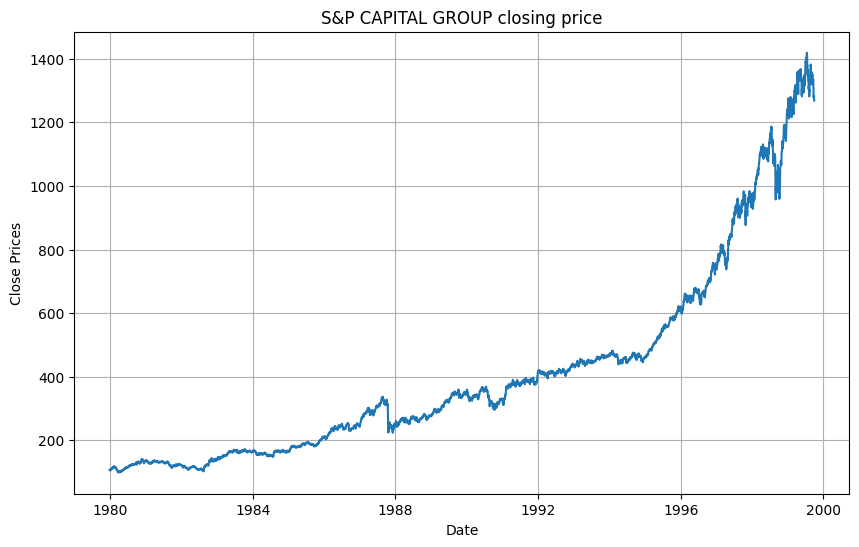

In [ ]:
#plot close price
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Close Prices')
plt.plot(stock_data['Close'])
plt.title('S&P CAPITAL GROUP closing price')
plt.show()

<Axes: ylabel='Density'>

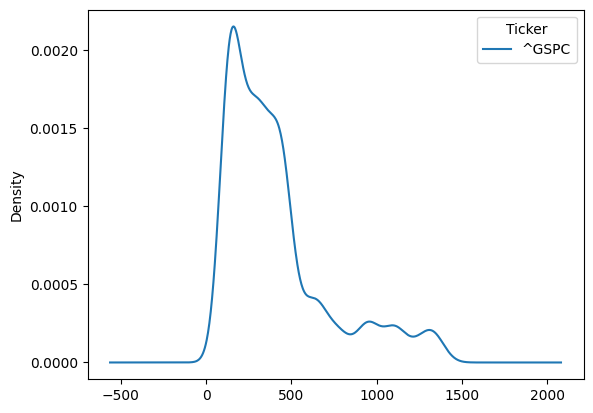

In [ ]:
#Distribution of the dataset
df_close = stock_data['Close']
df_close.plot(kind='kde')

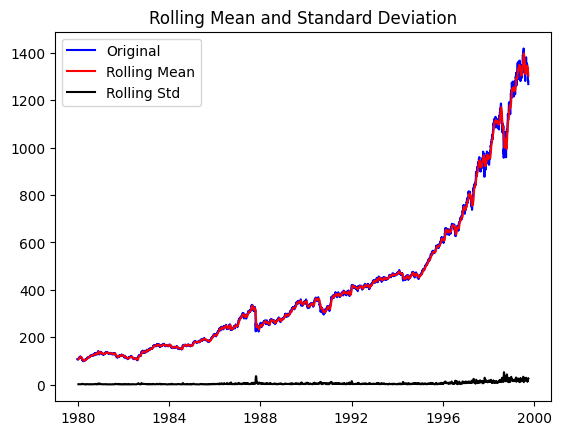

Results of dickey fuller test
Test Statistics                   2.593996
p-value                           0.999074
No. of lags used                 27.000000
Number of observations used    4967.000000
critical value (1%)              -3.431667
critical value (5%)              -2.862122
critical value (10%)             -2.567080
dtype: float64


In [ ]:
#Test for staionarity
def test_stationarity(timeseries):
    #Determing rolling statistics
    rolmean = timeseries.rolling(12).mean()
    rolstd = timeseries.rolling(12).std()
    #Plot rolling statistics:
    plt.plot(timeseries, color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean and Standard Deviation')
    plt.show(block=False)
    print("Results of dickey fuller test")
    adft = adfuller(timeseries,autolag='AIC')
    # output for dft will give us without defining what the values are.
    #hence we manually write what values does it explains using a for loop
    output = pd.Series(adft[0:4],index=['Test Statistics','p-value','No. of lags used','Number of observations used'])
    for key,values in adft[4].items():
        output['critical value (%s)'%key] =  values
    print(output)
test_stationarity(df_close)

<Axes: ylabel='Density'>

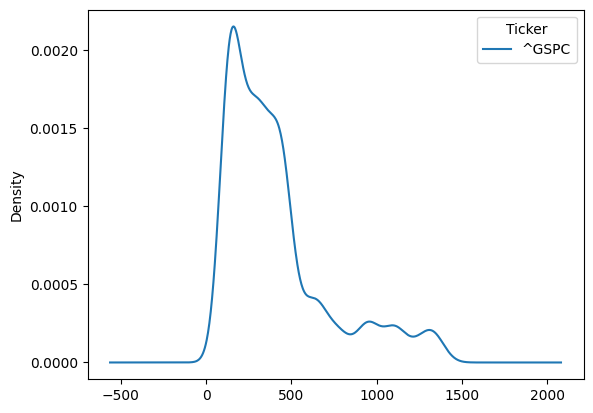

In [ ]:
#Distribution of the dataset
df_close = stock_data['Close']
df_close.plot(kind='kde')

<Figure size 640x480 with 0 Axes>

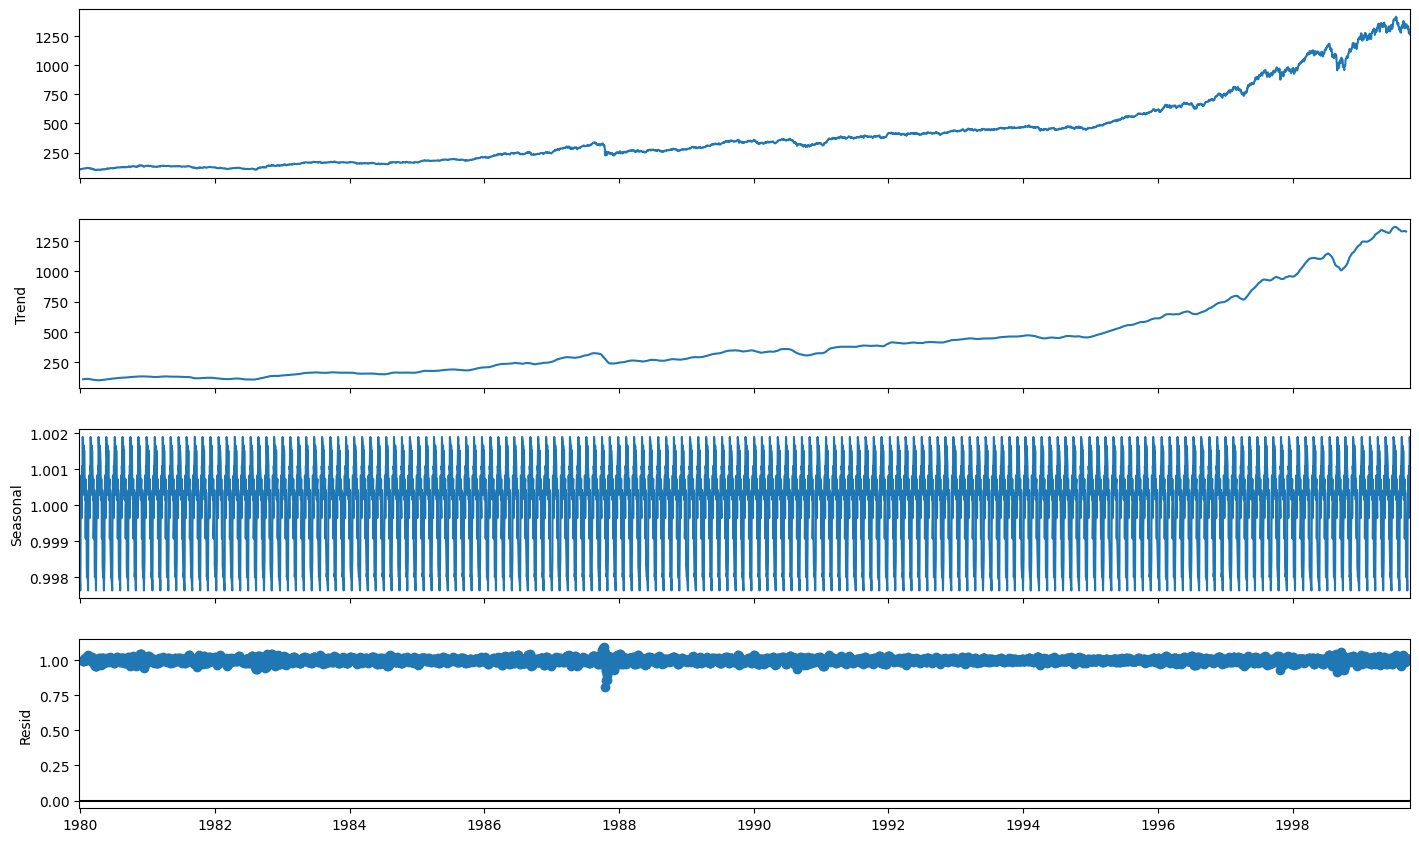

In [ ]:
#To separate the trend and the seasonality from a time series,
# we can decompose the series using the following code.
result = seasonal_decompose(df_close, model='multiplicative', period = 30)
fig = plt.figure()
fig = result.plot()
fig.set_size_inches(16, 9)

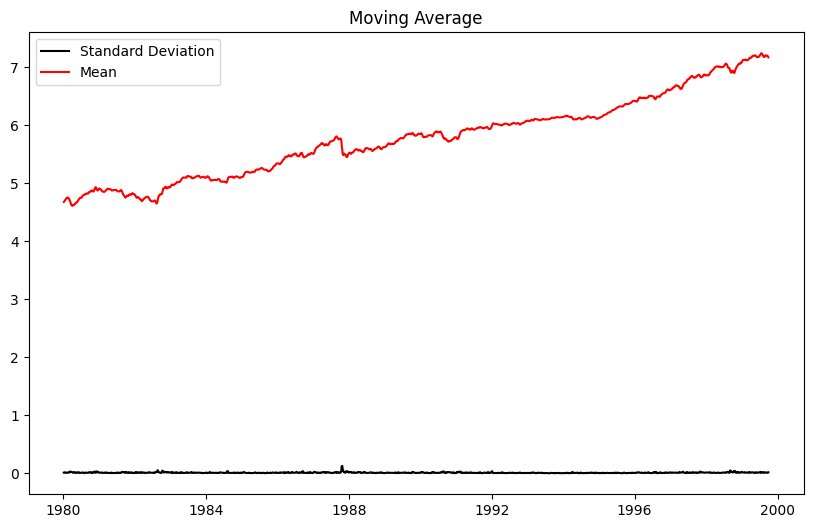

In [ ]:
#if not stationary then eliminate trend
#Eliminate trend
from pylab import rcParams
rcParams['figure.figsize'] = 10, 6
df_log = np.log(df_close)
moving_avg = df_log.rolling(12).mean()
std_dev = df_log.rolling(12).std()
plt.legend(loc='best')
plt.title('Moving Average')
plt.plot(std_dev, color ="black", label = "Standard Deviation")
plt.plot(moving_avg, color="red", label = "Mean")
plt.legend()
plt.show()

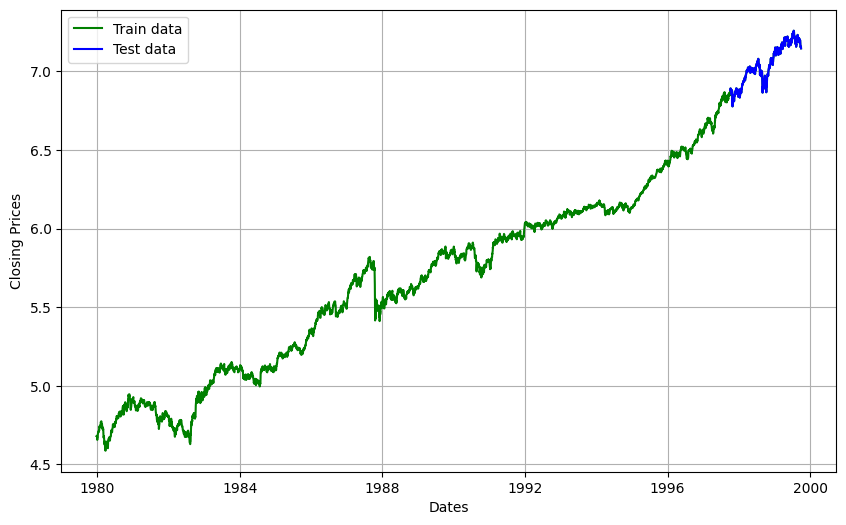

In [ ]:
#split data into train and training set
train_data, test_data = df_log[3:int(len(df_log)*0.9)], df_log[int(len(df_log)*0.9):]
test_data = test_data.replace(0, 1e-10)
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(df_log, 'green', label='Train data')
plt.plot(test_data, 'blue', label='Test data')
plt.legend()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-28951.483, Time=2.83 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-28962.434, Time=3.90 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-28963.422, Time=8.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-28941.981, Time=1.48 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-28964.008, Time=9.21 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-28967.128, Time=13.82 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-28967.621, Time=8.25 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-28969.413, Time=4.54 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-28967.105, Time=1.87 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-28959.644, Time=0.91 sec

Best model:  ARIMA(3,1,0)(0,0,0)[0] intercept
Total fit time: 55.112 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4492
Model:               SARIMAX(3, 1, 0)   

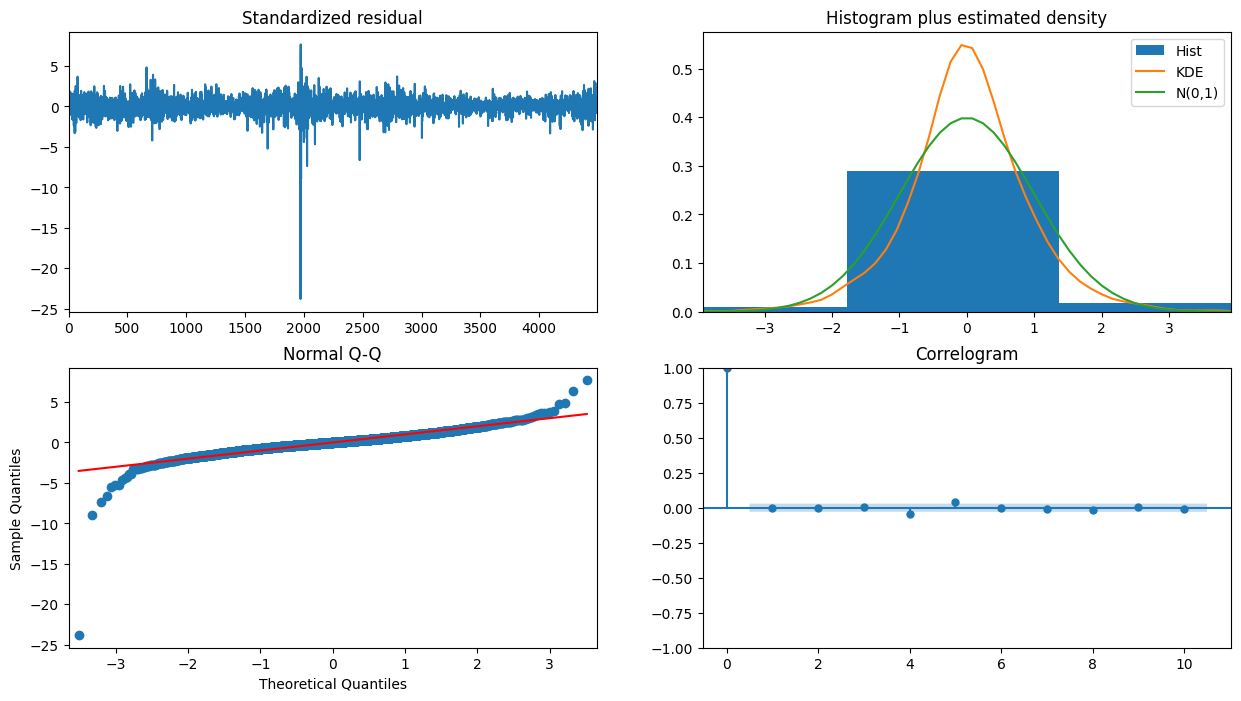

In [ ]:
model_autoARIMA = auto_arima(train_data, start_p=0, start_q=0,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0,
                      D=0,
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

In [ ]:
#As a result, the Auto ARIMA model assigned the values 1, 1, and 2 to, p, d, and q, respectively.
import statsmodels.api as smapi

model = smapi.tsa.arima.ARIMA(train_data, order=(3,1,0))

fitted = model.fit()
#Modeling
# Build Model
#model = ARIMA(train_data, order=(1,1,2))
#fitted = model.fit(disp=-1)
print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  ^GSPC   No. Observations:                 4492
Model:                 ARIMA(3, 1, 0)   Log Likelihood               14483.822
Date:                Sun, 20 Apr 2025   AIC                         -28959.644
Time:                        23:24:20   BIC                         -28934.005
Sample:                             0   HQIC                        -28950.609
                               - 4492                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0571      0.005     10.861      0.000       0.047       0.067
ar.L2         -0.0355      0.005     -7.350      0.000      -0.045      -0.026
ar.L3         -0.0265      0.006     -4.716      0.0

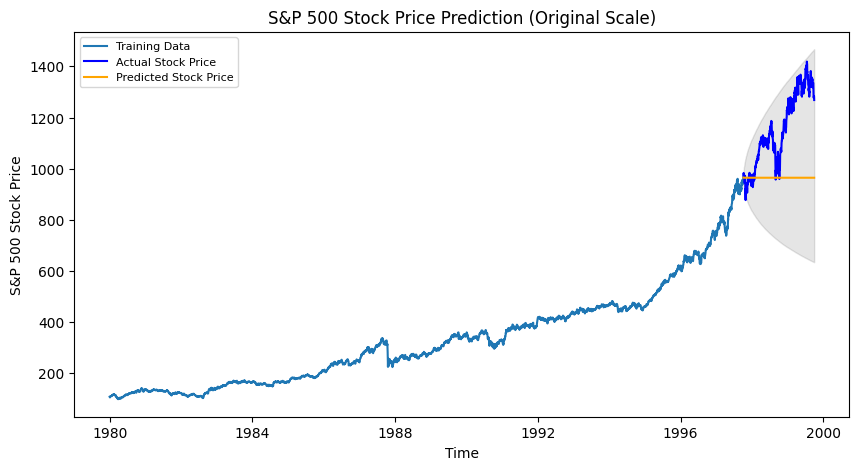

In [ ]:
# Forecast
forecast_result = fitted.get_forecast(steps=500)
fc = forecast_result.predicted_mean
conf = forecast_result.conf_int()

# Make as pandas series
# Make as pandas series

fc_series = pd.Series(fc.values, index=test_data.index)
lower_series = pd.Series(conf.iloc[:, 0].values, index=test_data.index)
upper_series = pd.Series(conf.iloc[:, 1].values, index=test_data.index)

fc_series_exp = np.exp(fc_series)
lower_series_exp = np.exp(lower_series)
upper_series_exp = np.exp(upper_series)
test_data_exp = np.exp(test_data)
train_data_exp = np.exp(train_data)

plt.figure(figsize=(10,5), dpi=100)
plt.plot(train_data_exp, label='Training Data')
plt.plot(test_data_exp, color='blue', label='Actual Stock Price')
plt.plot(fc_series_exp, color='orange', label='Predicted Stock Price')
plt.fill_between(lower_series_exp.index, lower_series_exp, upper_series_exp,
                 color='k', alpha=0.10)
plt.title('S&P 500 Stock Price Prediction (Original Scale)')
plt.xlabel('Time')
plt.ylabel('S&P 500 Stock Price')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [ ]:
# Replace NaN or infinite values with a small value or the mean
fc = np.nan_to_num(fc, nan=0.0, posinf=1e10, neginf=-1e10)
test_data = np.nan_to_num(test_data, nan=0.0, posinf=1e10, neginf=-1e10)

In [ ]:
fc_exp = np.exp(fc)
actual_exp = np.exp(test_data)

# Safety cleaning
fc_exp = np.nan_to_num(fc_exp, nan=0.0, posinf=1e10, neginf=-1e10)
actual_exp = np.nan_to_num(actual_exp, nan=0.0, posinf=1e10, neginf=-1e10)

# Ensure matching lengths
fc_exp = fc_exp[:len(actual_exp)]

mape = np.mean(np.abs(fc_exp - actual_exp) / np.abs(actual_exp))
print('MAPE (original scale):', mape)

MAPE (original scale): 0.15617777391723317


**The Following Code is for the LSTM model**

In [ ]:
import pandas as pd
from pandas_datareader import data
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import os
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from time import time
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import math

import warnings
warnings.filterwarnings("ignore")

[*********************100%***********************]  1 of 1 completed


Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 28s 119ms/step - loss: 0.0287
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - loss: 0.0020
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 127ms/step - loss: 0.0017
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - loss: 0.0016
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 156ms/step - loss: 0.0015
Epoch 6/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - loss: 0.0014
Epoch 7/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 127ms/step - loss: 0.0014
Epoch 8/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0012
Epoch 9/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - loss: 0.0012
Epoch 10/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - loss: 0.0011
Epoch 11/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - loss: 9.1970e-04
Epoch 12/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 127ms/step - loss: 9.5922e-04
Epoch 13/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 9.2788e-04
Epoch 14/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step - loss: 8.4454e-04

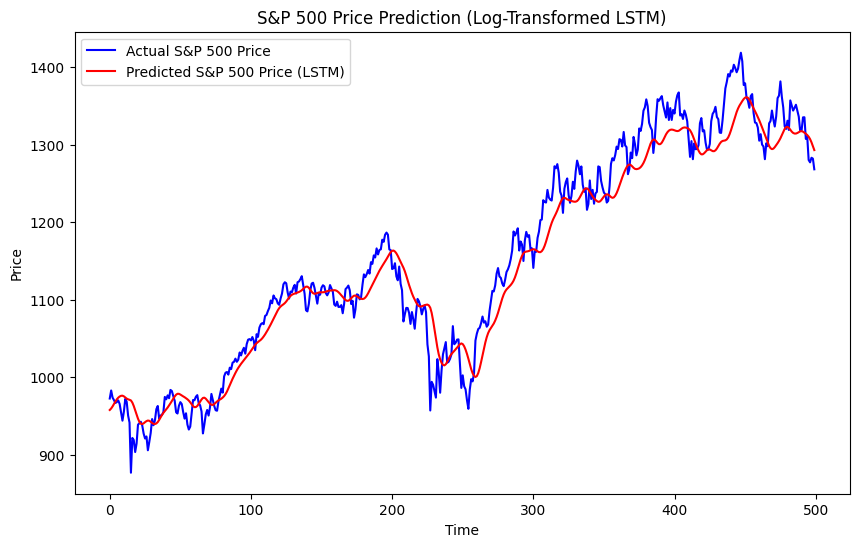

In [ ]:

stock_data = yf.download('^GSPC', start='1979-12-26', end='1999-09-30')
stock_data.reset_index(inplace=True)

# Use only the 'Close' column and apply log transformation
stock_data = stock_data[['Close']]
stock_data['LogClose'] = np.log(stock_data['Close'])

# Prepare log-transformed data for training
dataset = stock_data[['LogClose']].copy()
training_data_len = int(len(dataset) * 0.9)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# Create sequences
X_train = []
y_train = []
lookback = 60

for i in range(lookback, training_data_len):
    X_train.append(scaled_data[i-lookback:i, 0])
    y_train.append(scaled_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Build the LSTM model
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(50, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(50, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(50),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32)

# Prepare test data
test_data = scaled_data[training_data_len - lookback:]
X_test = []
for i in range(lookback, len(test_data)):
    X_test.append(test_data[i-lookback:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Predict and inverse transform
predicted_scaled = model.predict(X_test)
predicted_log = scaler.inverse_transform(predicted_scaled)
predicted_price = np.exp(predicted_log)  # <- reverse log transform

# Actual test values
actual_log = dataset[training_data_len:]
actual_price = np.exp(actual_log)

# Plot the results
plt.figure(figsize=(10,6))
plt.plot(actual_price.values, color='blue', label='Actual S&P 500 Price')
plt.plot(predicted_price, color='red', label='Predicted S&P 500 Price (LSTM)')
plt.title('S&P 500 Price Prediction (Log-Transformed LSTM)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import math

# Ensure both arrays are the same shape
actual = actual_price[:len(predicted_price)]

# Evaluation metrics
mse = mean_squared_error(actual, predicted_price)
mae = mean_absolute_error(actual, predicted_price)
rmse = math.sqrt(mse)
mape = np.mean(np.abs((actual - predicted_price) / actual)) * 100

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 1004.3911
MAE: 24.7995
RMSE: 31.6921
MAPE: 2.14%


In [ ]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 213,155 (832.64 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 142,104 (555.10 KB)

None
